# 14 — donor, FRET and acceptor measured separately

Three cuvettes, each measured on its own: the donor-only reference, the
labelled sample, and the acceptor-only reference. Two detectors, each recorded
parallel and perpendicular through the same instrument response.

This is the ensemble geometry the first ten notebooks of this series use, and
here it is as a *description* rather than as a literal list in the source. The
gate in notebook 11 asserts that the description produces exactly the eight
channel keys the prototype has written into it.

Note that this experiment has **two excitations and is not interleaved**: the
acceptor-only cuvette is measured in its own acquisition with its own laser, so
its acceptor is excited at full strength, while the labelled sample's acceptor
is only excited through the weak direct path `EX_AG`. Two lasers in two
acquisitions and two lasers in one period are different experiments, and the
description has to say which.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import experiment as X
from bd import P                      # the prototype, for the measured deviance reference


## The description


In [2]:
exp = X.separate_measurements()
print(exp.summary())


separate donor, FRET and acceptor measurements: 8 histograms
  samples     D0 (donor), DA (donor+acceptor), A0 (acceptor)
  excitations green at 0 ns, reaches donor x 1.0, acceptor x EX_AG, acceptor laser at 0 ns, reaches acceptor x 1.0
  detectors   g (green), r (red)
  histograms
    D0  g_vv     parallel      donor
    D0  g_vh     perpendicular donor
    DA  g_vv     parallel      donor + FRET + sensitised acceptor + acceptor directly (EX_AG)
    DA  g_vh     perpendicular donor + FRET + sensitised acceptor + acceptor directly (EX_AG)
    DA  r_vv     parallel      donor + FRET + sensitised acceptor + acceptor directly (EX_AG)
    DA  r_vh     perpendicular donor + FRET + sensitised acceptor + acceptor directly (EX_AG)
    A0  r_vv     parallel      acceptor directly
    A0  r_vh     perpendicular acceptor directly
  the donor-only sample's red channel is left out: it constrains the crosstalk, which is taken as calibrated here


The same description as JSON — this is what you would keep beside the data, and
what a program other than this notebook would read.


In [3]:
print(exp.to_json()[:700] + '\n...')
assert X.Experiment.from_json(exp.to_json()).to_dict() == exp.to_dict()


{
  "name": "separate donor, FRET and acceptor measurements",
  "notes": "the donor-only sample's red channel is left out: it constrains the crosstalk, which is taken as calibrated here",
  "interleaved": false,
  "samples": [
    {
      "name": "D0",
      "carries": [
        "donor"
      ]
    },
    {
      "name": "DA",
      "carries": [
        "donor",
        "acceptor"
      ]
    },
    {
      "name": "A0",
      "carries": [
        "acceptor"
      ]
    }
  ],
  "excitations": [
    {
      "name": "green",
      "excites": {
        "donor": 1.0,
        "acceptor": "EX_AG"
      },
      "delay_ns": 0.0
    },
    {
      "name": "acceptor laser",
      "excites": {
      
...


## What this experiment can and cannot determine

Before fitting anything. Each unknown is moved and the change in every
histogram measured; the share is how much of what the posterior will say comes
from the data rather than from the prior. **A share near zero is conclusive**:
nothing in the data moves, so whatever the fit prints for it is the prior. A
share near one is not conclusive — this is the diagonal, and a coordinate can
still be undetermined through a correlation.


In [4]:
model = X.build(exp, knots=25)
rows = X.identifiability(exp, model)
print(f'{"unknown":<16}{"group":<7}{"data share":>11}   carried by')
for r in sorted(rows, key=lambda r: r['data_share'])[:12]:
    print(f'{r["variable"]:<16}{r["role"]:<7}{r["data_share"]:>11.4f}   {r["carried_by"]}')
blind = X.unidentified(rows)
print(f'\n{len(blind)} of {len(rows)} unknowns are moved by nothing in these data:')
print('  ' + ', '.join(r['variable'] for r in blind))


  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt


unknown         group   data share   carried by
log10_lam       hyper       0.0000   nothing
l1              cal         0.9456   DA g_vv, D0 g_vv, A0 r_vv
r0_d            phys        0.9555   DA g_vv, D0 g_vv, DA g_vh
l2              cal         0.9691   DA g_vh, D0 g_vh, A0 r_vh
C_GA            cal         0.9728   DA g_vv, DA g_vh
r0_a            phys        0.9747   A0 r_vv, A0 r_vh, DA r_vv
bkg_D0_g_vh     inst        0.9868   D0 g_vh
w_rho_a         phys        0.9889   A0 r_vv, DA r_vv, A0 r_vh
bkg_DA_g_vh     inst        0.9941   DA g_vh
bkg_D0_g_vv     inst        0.9946   D0 g_vv
w_rho           phys        0.9955   DA g_vv, D0 g_vv, DA g_vh
c               phys        0.9966   DA r_vv, DA r_vh, DA g_vv

1 of 42 unknowns are moved by nothing in these data:
  log10_lam


## Data from that description

A mixture of two populations, one at $R/R_0 = 0.85$ and a broader one at 1.25,
simulated through the same forward model the fit uses and given Poisson noise.
No bursts and no selection: this is the idealised measurement, so that anything
the fit gets wrong is the *inference's* fault and not the experiment's.


In [5]:
rel = model['rel']
p_true = (np.exp(-0.5 * ((rel - 0.85) / 0.07) ** 2)
          + 0.6 * np.exp(-0.5 * ((rel - 1.25) / 0.09) ** 2))
p_true = p_true / p_true.sum()
y, lam_true, vals = X.simulate(exp, model, p_true, photons=3e5, seed=1)
for k in model['keys']:
    print(f'{k[0]:<3} {k[1]:<8} {float(y[k].sum()):>10,.0f} photons')


D0  g_vv        308,843 photons
D0  g_vh        211,803 photons
DA  g_vv        309,441 photons
DA  g_vh        197,381 photons
DA  r_vv        299,208 photons
DA  r_vh        242,521 photons
A0  r_vv        307,906 photons
A0  r_vh        232,733 photons


## The fit

The roughness weight of the P-spline prior on $\log p(R/R_0)$ is not maximised
but integrated out: a Laplace approximation at each node of a grid, the nodes
mixed by their evidences.


In [6]:
import time
t0 = time.time()
g, post = X.fit(exp, model, y, lam_nodes=(1.0, 0.0, -1.0))
print(f'{time.time() - t0:.0f} s')


/Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/s88_laplace_posterior.py:2933: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:837.)
  evid = -float(f2) + 0.5 * graph.dim * math.log(2 * math.pi) - 0.5 * logdet



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/tpeulen/mambaforge/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/tpeulen/mambaforge/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/tpeulen/mambaforge/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/tpeulen/mambaforge/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/tpeulen/mambaforge/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/tpeulen/mambaforge/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/tpeulen/mambaforge/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/tpeulen/mambaforge/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/tpeulen/mambaforge/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/tpeulen/mambaforge/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/Users/tpeulen/mambaforge/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/tpeulen/mambaforge/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start

110 s


## Rule 0

No number about a fitted quantity is reportable without the weighted residuals
and the fit statistic. The Poisson deviance per degree of freedom is compared
with a **measured** reference and not with 1: the deviance of a correct model
at these counts is close to the number of *bins*, while the reported degrees of
freedom subtract the whole parameter dimension even though a penalised spline
uses far fewer of them. So the reference is Poisson draws at the fitted means.


In [7]:
ref_mean, ref_sd = P.poisson_reference(post, n_draw=200, seed=0)
print(f'{"histogram":<14}{"photons":>12}{"D/dof":>9}{"runs p":>9}')
for r in X.rule0(model, g, post, y):
    print(f'{r["channel"]:<14}{r["counts"]:>12,.0f}{r["dpd"]:>9.3f}{r["runs_p"]:>9.3f}')
z = (post['dev'] / post['dof'] - ref_mean) / ref_sd
print(f'\nreference D/dof (Poisson draws at the fitted means): {ref_mean:.3f} +- {ref_sd:.3f}')
print(f'this fit: {post["dev"] / post["dof"]:.3f}, which is {z:+.1f} reference sd')
print('VERDICT:', 'passes' if abs(z) < 3 else 'FAILS -- this result is excluded and counted')


histogram          photons    D/dof   runs p
D0 g_vv            308,843    0.923    0.279
D0 g_vh            211,803    1.131    0.599
DA g_vv            309,441    1.096    0.483
DA g_vh            197,381    1.030    0.858
DA r_vv            299,208    0.946    0.324
DA r_vh            242,521    1.079    0.479
A0 r_vv            307,906    1.191    0.560
A0 r_vh            232,733    1.178    0.589
all              2,109,836    1.072      nan

reference D/dof (Poisson draws at the fitted means): 1.120 +- 0.047
this fit: 1.072, which is -1.0 reference sd
VERDICT: passes


In [8]:
ks = list(g.data_keys)
n = len(ks)
fig, axes = plt.subplots(2, n, figsize=(3.4 * n, 5.0), sharex=True,
                         gridspec_kw=dict(height_ratios=[2.2, 1.0]))
axes = np.atleast_2d(axes).reshape(2, n)
tc = model['Eu']['tc']; wid = model['Eu']['wid']
for j, k in enumerate(ks):
    a, ar = axes[0, j], axes[1, j]
    yk = np.asarray(y[k]); lk = np.asarray(post['lam'][k])
    a.semilogy(tc, np.maximum(yk, 0.3) / wid, 'k.', ms=2, label='data')
    a.semilogy(tc, np.clip(lk, 1e-3, None) / wid, 'C3-', lw=1.0, label='fit')
    r = post['rows'][k]
    a.set_title(f'{k[0]} {k[1]}\nD/dof {r["dpd"]:.3f}, runs p {r["runs_p"]:.2f}', fontsize=9)
    if j == 0:
        a.set_ylabel('counts per ns'); a.legend(fontsize=8)
    ar.plot(tc, r['w'], lw=0.6, color='C3'); ar.axhline(0, color='k', lw=0.5)
    ar.set_ylim(-5.5, 5.5); ar.set_xlabel('time / ns')
    if j == 0:
        ar.set_ylabel('weighted residual')
fig.tight_layout(); plt.show()


/var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/ipykernel_21205/2086981411.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.tight_layout(); plt.show()


## What came back

The posterior over the distance distribution, with the band the delta method
gives, against the truth it was simulated from.


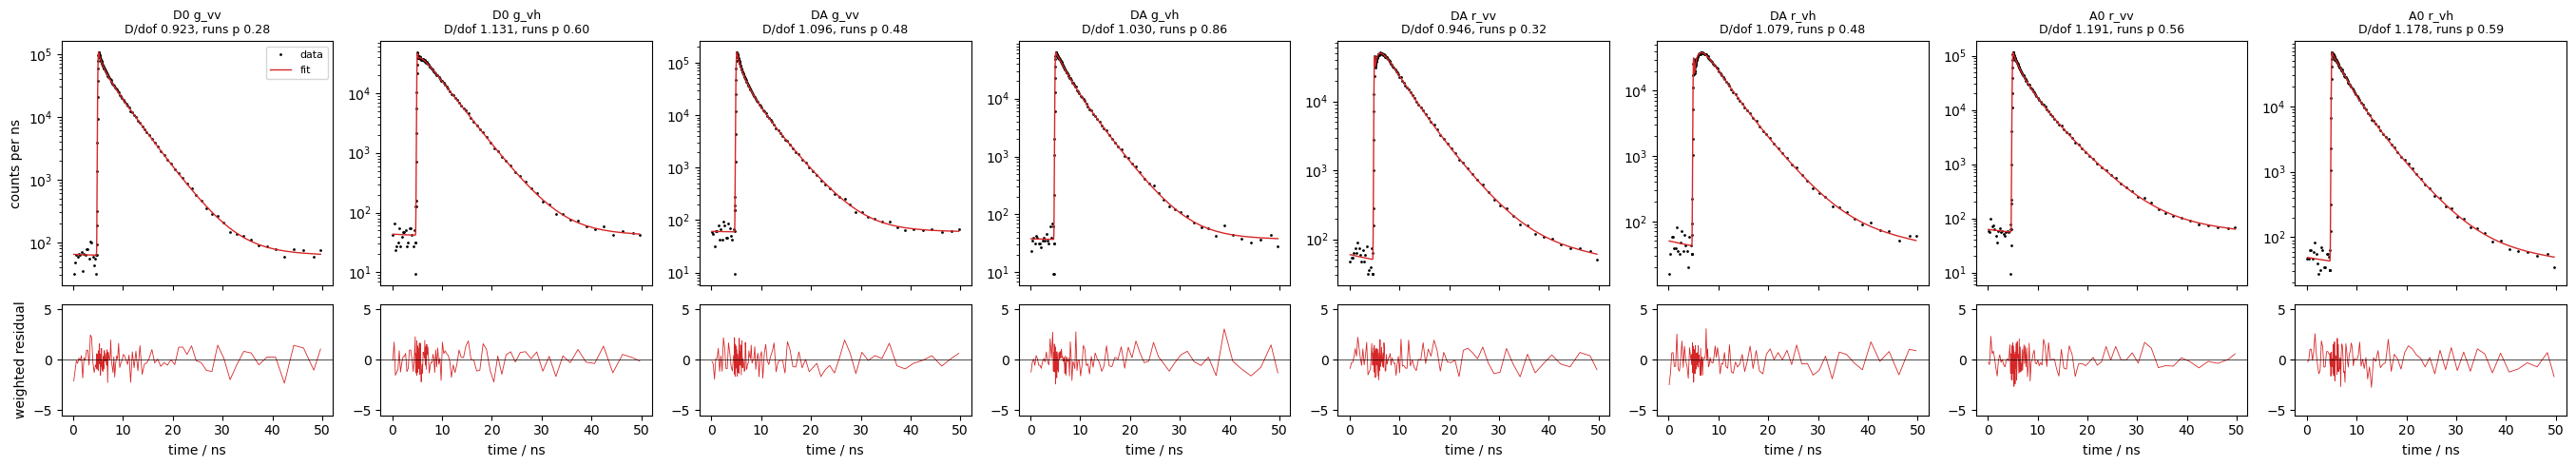

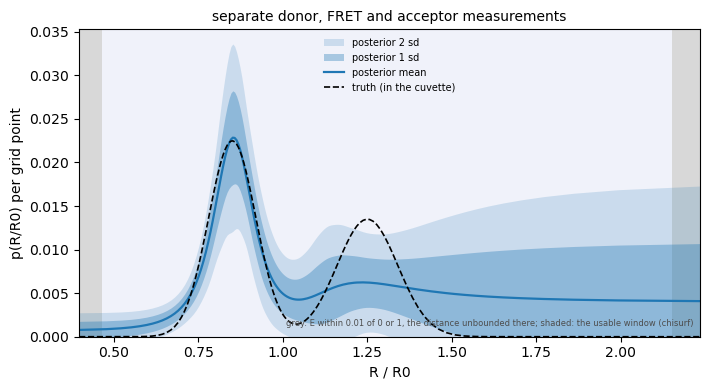

mean R/R0:  truth 0.9746   posterior 0.9906
the evidence mixture put weights [2.000e-04 5.000e-04 1.200e-03 3.000e-03 7.700e-03 1.950e-02 4.460e-02
 9.670e-02 1.623e-01 2.118e-01 2.068e-01 1.508e-01 9.510e-02] on log10 lambda = [-1.5, -1.25, -1.0, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]


In [9]:
fig = P.plot_pR(model, post, p_true=p_true, title=exp.name)
plt.show()
m, lo1, hi1, lo2, hi2 = model['L'].delta_bands(None, post, rel, space='linear')
mean_true = float((p_true * rel).sum()); mean_fit = float((m * rel).sum())
print(f'mean R/R0:  truth {mean_true:.4f}   posterior {mean_fit:.4f}')
print(f'the evidence mixture put weights {np.round(post["weights"], 4)} on '
      f'log10 lambda = {post["lam_nodes"]}')


## What the two references buy

Compare the identifiability table above with notebook 12's. The donor-only
cuvette measures the unquenched donor where no transfer can contaminate it, and
the acceptor-only cuvette measures the acceptor's decay and anisotropy where no
donor can. Every unknown they pin down is one the labelled sample no longer has
to pay for.
